In [8]:
#Author: Thomas Cooper
#date: 7.1.2026


#packages
import os 
import pandas as pd                                 ## dataframe framework
import numpy as np                                  ## provides library of basic mathematical functions
import matplotlib.pyplot as plt                     ## necessary for plotting
import statsmodels.formula.api as smf               ## necessary for regressions
import statsmodels.api as sm                        ##Allows probit models
from statsmodels.iolib.summary2 import summary_col  ## enables you to save regression results 
import seaborn as sns                               #Graphs regressions nicely
import matplotlib.dates as mdates                   #Helps to manage datetime for seaborn
from scipy.optimize import brentq                   #Finds the root of a function
import rasterio
import matplotlib.animation as animation
from rasterio.transform import Affine
from IPython.display import HTML
from matplotlib.colors import ListedColormap

#Load sim data
df = pd.read_excel("na_optimistic_sim.xlsx")
df['stage_ft_NVD88'] = df['stage_m_NVD88']*3.28084 #Keep it in NVGD 88
df['year'] = df['dates'].dt.year
df.head()

,Column1,days,dates,stage_m_NVD88,vol,area,stage-ft_NGVD29,Unnamed: 7,2027-12-31 00:00:00,Unnamed: 9,stage_ft_NVD88,year
0,0,0,2026-09-01,1278.178800,3.510000,930.810000,4190.024275,NaN,NaN,NaN,4193.500134,2026
1,1,1,2026-09-02,1278.167920,3.504304,929.790503,4189.988578,NaN,NaN,NaN,4193.464438,2026
2,2,2,2026-09-03,1278.160089,3.498614,929.055635,4189.962888,NaN,NaN,NaN,4193.438748,2026
3,3,3,2026-09-04,1278.158356,3.492928,928.873696,4189.957203,NaN,NaN,NaN,4193.433062,2026
4,4,4,2026-09-05,1278.145799,3.487244,927.670186,4189.916005,NaN,NaN,NaN,4193.391865,2026


In [10]:
#Elevation Function from the sim dataset
def elevation(t):
    return df.loc[t, 'stage_ft_NVD88']

#Year Func
def year(t):
    return df.loc[t, 'year']

In [12]:
#X and Y bounds for north arm
x_max = 375000
y_min = 4565000

#Colormap bc I just want it plain blue
blue = ListedColormap(['darkblue'])

In [14]:
def load_lake(step=16):
    npy_path = "great_salt_lake_downsampled_with_meta.npz"
    ds_dat = np.load(npy_path)
    data = ds_dat["data"]
    transform = ds_dat["transform"]

    affine = Affine(
        transform[1], transform[2], transform[0],
        transform[4], transform[5], transform[3])

    raw = data.astype(np.float32)
    raw[raw == 0] = np.nan          # keep out-of-bounds as NaN permanently

    raw = raw[::step, ::step]
    nrows, ncols = raw.shape
    cols = np.arange(0, ncols * step, step)
    rows = np.arange(0, nrows * step, step)

    x = affine.c + cols * affine.a
    y = affine.f + rows * affine.e

    col_mask = x < x_max
    row_mask = y > y_min

    raw = raw[np.ix_(row_mask, col_mask)]
    x = x[col_mask]
    y = y[row_mask]

    extent = [x.min(), x.max(), y.min(), y.max()]
    origin = 'upper' if y[0] > y[-1] else 'lower'

    return raw, extent, origin

def animate_lake(n_frames=100, step=16, interval_ms=80, save_path=None):
    raw, extent, origin = load_lake(step=step)

    fig, ax = plt.subplots(figsize=(10, 8))

    t0 = df.index[0]
    level0 = elevation(0)
    year0 = year(0)
    frame0 = np.where(raw > level0, np.nan, raw)
    title = ax.set_title(f"Forecasted Great Salt Lake Surface Area in {year0:}")

    im = ax.imshow(frame0, extent=extent, origin=origin, cmap=blue,
                    vmin=np.nanmin(raw), vmax=np.nanmax(raw))
    ax.axis("equal")
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    def update(t):
        level = elevation(t)
        frame = np.where(raw > level, np.nan, raw)
        im.set_data(frame)
        title.set_text(f"Forecasted Great Salt Lake Surface Area in {year(t)}")
        return im, title

    ani = animation.FuncAnimation(
        fig, update, frames=df.index[::30], interval=interval_ms, blit=False
    )

    if save_path:
        ani.save(save_path, writer='pillow' if save_path.endswith('.gif') else 'ffmpeg')
    else:
        plt.show()

    return ani




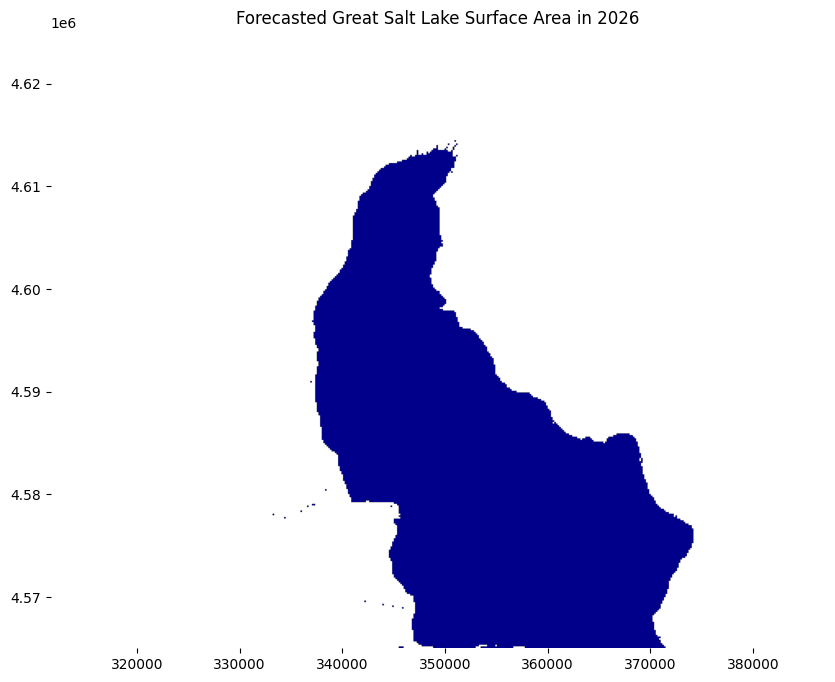

In [16]:
if __name__ == "__main__":
    ani = animate_lake(n_frames=100, step=16, save_path="na_lake_decline.gif")

HTML(ani.to_jshtml())